<a href="https://colab.research.google.com/github/amanbhatia-analyst/exploring-food-data-/blob/main/food%20coded%20data%20analysis%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Define the file path (update this path accordingly)
file_path = "/content/drive/My Drive/My Documents/food_coded_data.xlsx"

In [ ]:
# Load the dataset
df = pd.read_excel(file_path)

# Display basic info
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    floa

In [ ]:
# Display first few rows
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
     GPA  Gender  breakfast  calories_chicken  calories_day  calories_scone  \
0    2.4       2          1               430           NaN           315.0   
1  3.654       1          1               610           3.0           420.0   
2    3.3       1          1               720           4.0           420.0   
3    3.2       1          1               430           3.0           420.0   
4    3.5       1          1               720           2.0           420.0   

   coffee                      comfort_food        comfort_food_reasons  \
0       1                              none        we dont have comfort   
1       2       chocolate, chips, ice cream        Stress, bored, anger   
2       2   frozen yogurt, pizza, fast food             stress, sadness   
3       2  Pizza, Mac and cheese, ice cream                     Boredom   
4       2      Ice cream, chocolate, chips   Stress, boredom, cravings    

   comfort_food_reasons_coded  ...  soup  sports  thai_food

In [ ]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
GPA                  2
Gender               0
breakfast            0
calories_chicken     0
calories_day        19
                    ..
type_sports         27
veggies_day          0
vitamins             0
waffle_calories      0
weight               2
Length: 61, dtype: int64


In [ ]:
### Handling Missing Values ###
# Fill missing numeric values with mean
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.mean()))

# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(include=["object"]).columns
df[categorical_cols] = df[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))

print("✅ Missing values handled successfully.")

✅ Missing values handled successfully.


<ipython-input-13-da516ade58c1>:8: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'int'
  df[categorical_cols] = df[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))


In [ ]:
### Data Cleaning and Preprocessing ###
# Convert 'GPA' to numeric
df["GPA"] = pd.to_numeric(df["GPA"], errors="coerce")

# Handling inconsistent values in 'weight'
df["weight"] = df["weight"].str.extract(r'(\d+)')  # Extract numeric part
df["weight"] = pd.to_numeric(df["weight"], errors="coerce")

In [ ]:
### Exploratory Data Analysis (EDA) ###
# Summary statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
              GPA      Gender   breakfast  calories_chicken  calories_day  \
count  122.000000  125.000000  125.000000        125.000000    125.000000   
mean     3.718582    1.392000    1.112000        577.320000      3.028302   
std      2.723390    0.490161    0.316636        131.214156      0.588294   
min      2.200000    1.000000    1.000000        265.000000      2.000000   
25%      3.200000    1.000000    1.000000        430.000000      3.000000   
50%      3.500000    1.000000    1.000000        610.000000      3.000000   
75%      3.700000    2.000000    1.000000        720.000000      3.028302   
max     32.000000    2.000000    2.000000        720.000000      4.000000   

       calories_scone     coffee  comfort_food_reasons_coded        cook  \
count      125.000000  125.00000                  125.000000  125.000000   
mean       505.241935    1.75200                    2.698113    2.786885   
std        229.907814    0.43359                    1.814

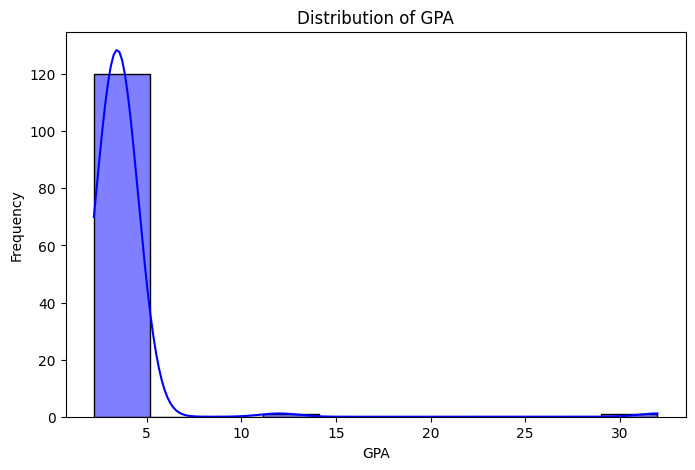

In [ ]:
# Histogram of GPA
plt.figure(figsize=(8, 5))
sns.histplot(df["GPA"], bins=10, kde=True, color="blue")
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")
plt.show()

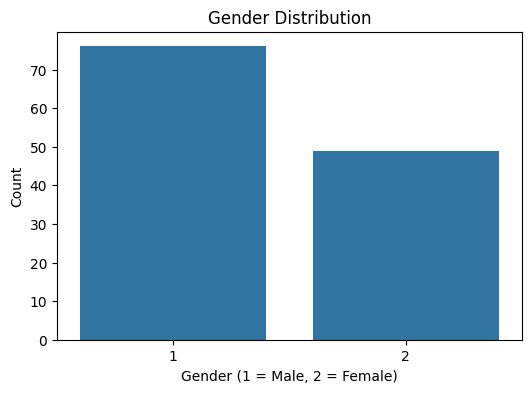

In [ ]:
# Countplot for Gender
plt.figure(figsize=(6, 4))
sns.countplot(x=df["Gender"])
plt.title("Gender Distribution")
plt.xlabel("Gender (1 = Male, 2 = Female)")
plt.ylabel("Count")
plt.show()

In [ ]:
print("✅ EDA completed.")

✅ EDA completed.


In [ ]:
# Select only relevant columns
selected_vars = ["GPA", "breakfast", "calories_day", "sports", "weight"]
df_selected = df[selected_vars]

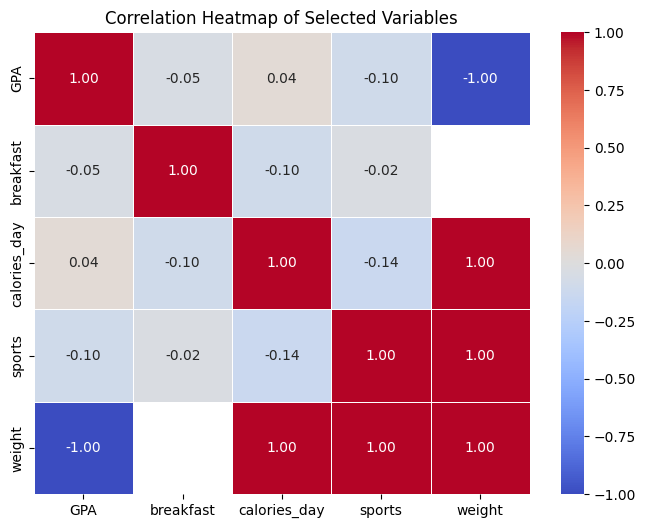

In [ ]:
### Correlation Heatmap ###
plt.figure(figsize=(8, 6))
sns.heatmap(df_selected.corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Selected Variables")
plt.show()

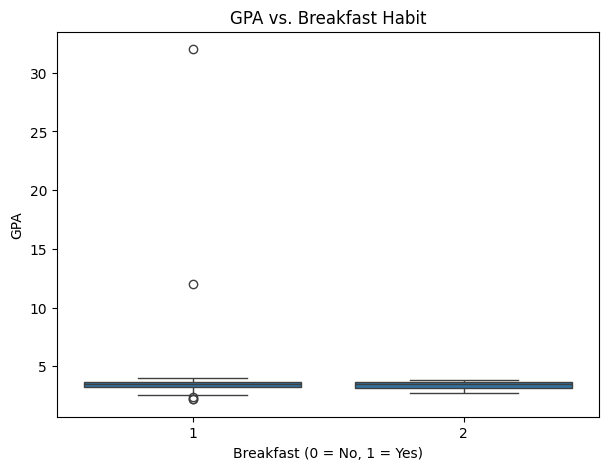

In [ ]:
# GPA vs. Breakfast habit
plt.figure(figsize=(7, 5))
sns.boxplot(x=df["breakfast"], y=df["GPA"])
plt.title("GPA vs. Breakfast Habit")
plt.xlabel("Breakfast (0 = No, 1 = Yes)")
plt.ylabel("GPA")
plt.show()

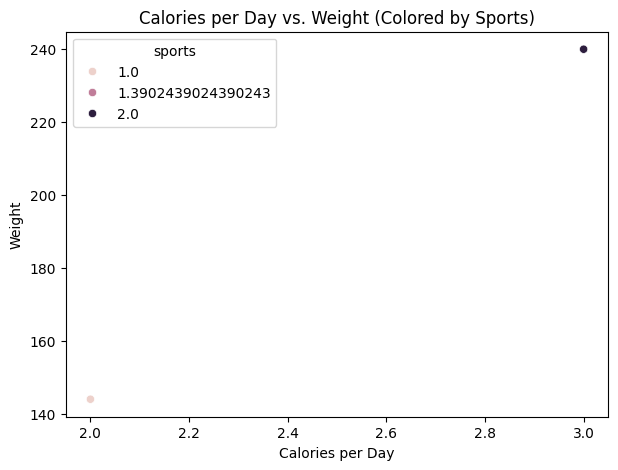

✅ Statistical analysis and visualizations completed.


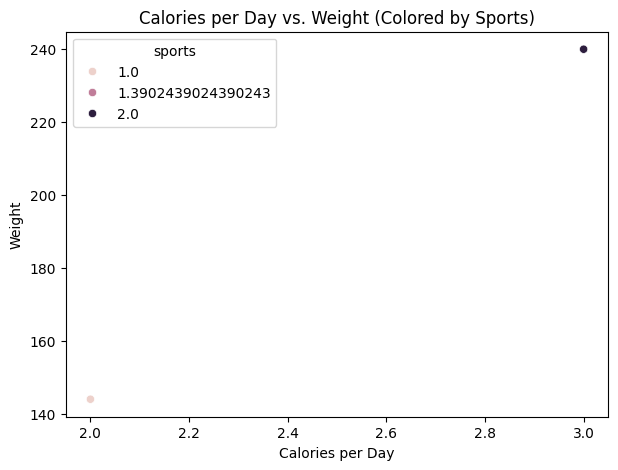

✅ Statistical analysis and visualizations completed.


In [ ]:
### Scatter Plot: Calories per Day vs. Weight ###
plt.figure(figsize=(7, 5))
sns.scatterplot(x=df_selected["calories_day"], y=df_selected["weight"], hue=df_selected["sports"])
plt.title("Calories per Day vs. Weight (Colored by Sports)")
plt.xlabel("Calories per Day")
plt.ylabel("Weight")
plt.show()

print("✅ Statistical analysis and visualizations completed.")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/stakeholder_map.png'

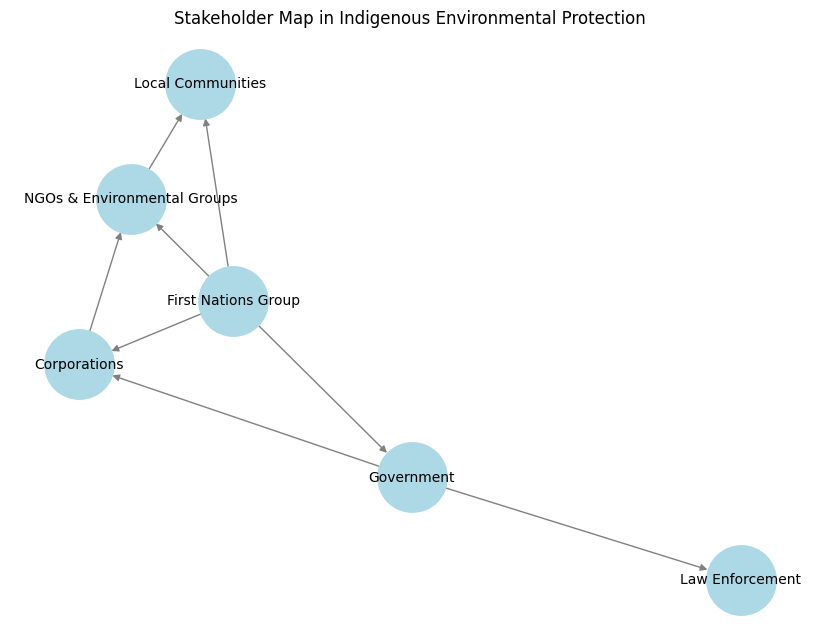

In [ ]:
# Re-import necessary library since the execution state was reset
import matplotlib.pyplot as plt

import networkx as nx

# Create a stakeholder map
G = nx.DiGraph()

# Add nodes (stakeholders)
stakeholders = [
    "First Nations Group", "Government", "Corporations",
    "NGOs & Environmental Groups", "Law Enforcement", "Local Communities"
]

for stakeholder in stakeholders:
    G.add_node(stakeholder)

# Define relationships (edges)
edges = [
    ("First Nations Group", "Government"),
    ("First Nations Group", "Corporations"),
    ("First Nations Group", "NGOs & Environmental Groups"),
    ("First Nations Group", "Local Communities"),
    ("Government", "Corporations"),
    ("Government", "Law Enforcement"),
    ("Corporations", "NGOs & Environmental Groups"),
    ("NGOs & Environmental Groups", "Local Communities"),
]

G.add_edges_from(edges)

# Draw the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # Layout for better visualization
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=2500, font_size=10)
plt.title("Stakeholder Map in Indigenous Environmental Protection")

# Save the figure
stakeholder_map_path = "/mnt/data/stakeholder_map.png"
plt.savefig(stakeholder_map_path)
plt.show()

# Return the image path
stakeholder_map_path

In [ ]:
# Define the file path (update this path accordingly)
file_path = "/content/drive/My Drive/My Documents/food_coded_data.xlsx"

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/timeline_of_events.png'

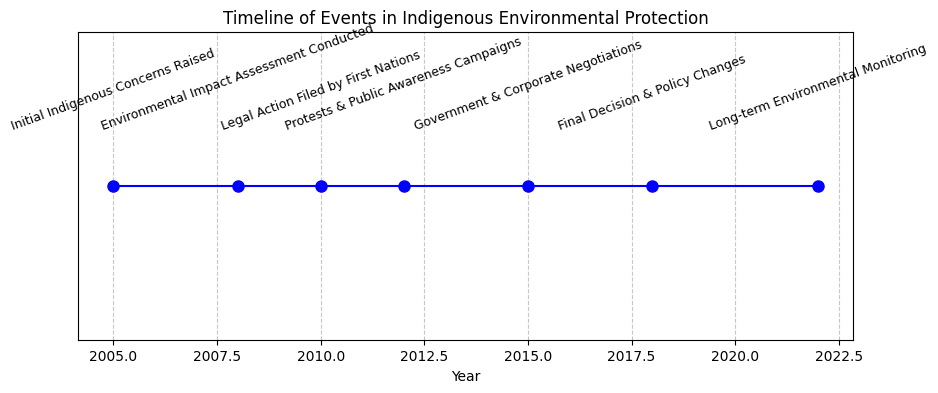

In [ ]:
# Create a timeline of events for the case study
events = [
    "Initial Indigenous Concerns Raised",
    "Environmental Impact Assessment Conducted",
    "Legal Action Filed by First Nations",
    "Protests & Public Awareness Campaigns",
    "Government & Corporate Negotiations",
    "Final Decision & Policy Changes",
    "Long-term Environmental Monitoring"
]

years = [2005, 2008, 2010, 2012, 2015, 2018, 2022]

plt.figure(figsize=(10, 4))
plt.plot(years, [1] * len(years), "bo-", label="Key Events", markersize=8)

for i, event in enumerate(events):
    plt.text(years[i], 1.02, event, ha="center", fontsize=9, rotation=20)

plt.yticks([])  # Hide y-axis
plt.xlabel("Year")
plt.title("Timeline of Events in Indigenous Environmental Protection")
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Save the figure
timeline_path = "/mnt/data/timeline_of_events.png"
plt.savefig(timeline_path)
plt.show()

# Return the image path
timeline_path


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Given bond data
bond_data = pd.DataFrame({
    "Maturity (years)": [1, 2, 2, 3, 3, 4, 5, 6, 7, 7, 8, 9, 10, 11, 11, 12, 13, 14, 14, 15, 16, 16, 17, 18, 19, 19, 20],
    "Bond Price": [100.85, 101.07, 102.22, 102.27, 102.50, 103.98, 103.94, 97.24, 92.25, 91.90, 101.75, 96.00, 89.17, 78.50, 86.87, 89.24, 92.48, 72.92, 82.82, 77.00, 64.10, 59.00, 69.13, 52.06, 56.61, 53.82, 51.04],
    "Coupon": [4.00, 4.00, 4.50, 4.50, 4.00, 5.00, 5.00, 4.00, 3.50, 3.50, 5.50, 5.00, 4.00, 3.00, 4.00, 4.50, 5.00, 3.00, 4.00, 3.50, 2.50, 2.00, 3.00, 1.50, 2.00, 1.50, 1.50]
})

# Function to calculate yield to maturity (YTM)
def ytm(face_value, price, coupon, years):
    return np.roots([1] + [-coupon] * years + [-(face_value - price)])[0].real

face_value = 100  # Assuming face value of 100 for all bonds

# Calculate YTM for each bond
bond_data["Yield"] = bond_data.apply(lambda row: ytm(face_value, row["Bond Price"], row["Coupon"], row["Maturity (years)"]), axis=1)

# Plot yield curve
plt.figure(figsize=(10, 5))
plt.scatter(bond_data["Maturity (years)"], bond_data["Yield"], color='blue', label="Observed Yields")
plt.plot(bond_data["Maturity (years)"], bond_data["Yield"], linestyle='--', color='red', label="Yield Curve")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.title("Yield Curve for AAA Corporate Bonds")
plt.legend()
plt.grid()
plt.show()

# Compute yield spread (10-year - 1-year)
yield_10_year = bond_data[bond_data["Maturity (years)"] == 10]["Yield"].values[0]
yield_1_year = bond_data[bond_data["Maturity (years)"] == 1]["Yield"].values[0]
yield_spread = yield_10_year - yield_1_year

yield_spread

TypeError: can't multiply sequence by non-int of type 'numpy.float64'